# Meteograms 

## For Control Simulation and Smooth Terrain Simulation
### uses rolling average window of 12 hrs
### The propagation angle are computed using Koch and O'Handley (1997) approach of vector mean in conditionally stable layer


Data directory: /glade/work/rbhandari/data/SIM_Feb14_MP2
Readable files used: 97
Skipped files: 0
Time start: 1992-02-14 06:00:00
Time end:   1992-02-15 06:00:00
Unique dt seconds: [900]

Data directory: /glade/derecho/scratch/rbhandari/SMOOTH-Terrain1/wrfv4.6.1/test/em_real
Readable files used: 97
Skipped files: 0
Time start: 1992-02-14 06:00:00
Time end:   1992-02-15 06:00:00
Unique dt seconds: [900]


/glade/u/apps/opt/conda/envs/npl-2024a/lib/python3.11/site-packages/numpy/core/fromnumeric.py:59: UserWarning: Warning: 'argpartition' will ignore the 'mask' of the MaskedArray.
  return bound(*args, **kwds)



Shared axis limits used for both CNTRL and SMT:
p′ axis: -3.0 to 2.0 hPa
Precipitation axis: 0.0 to 11.056209564208984 mm


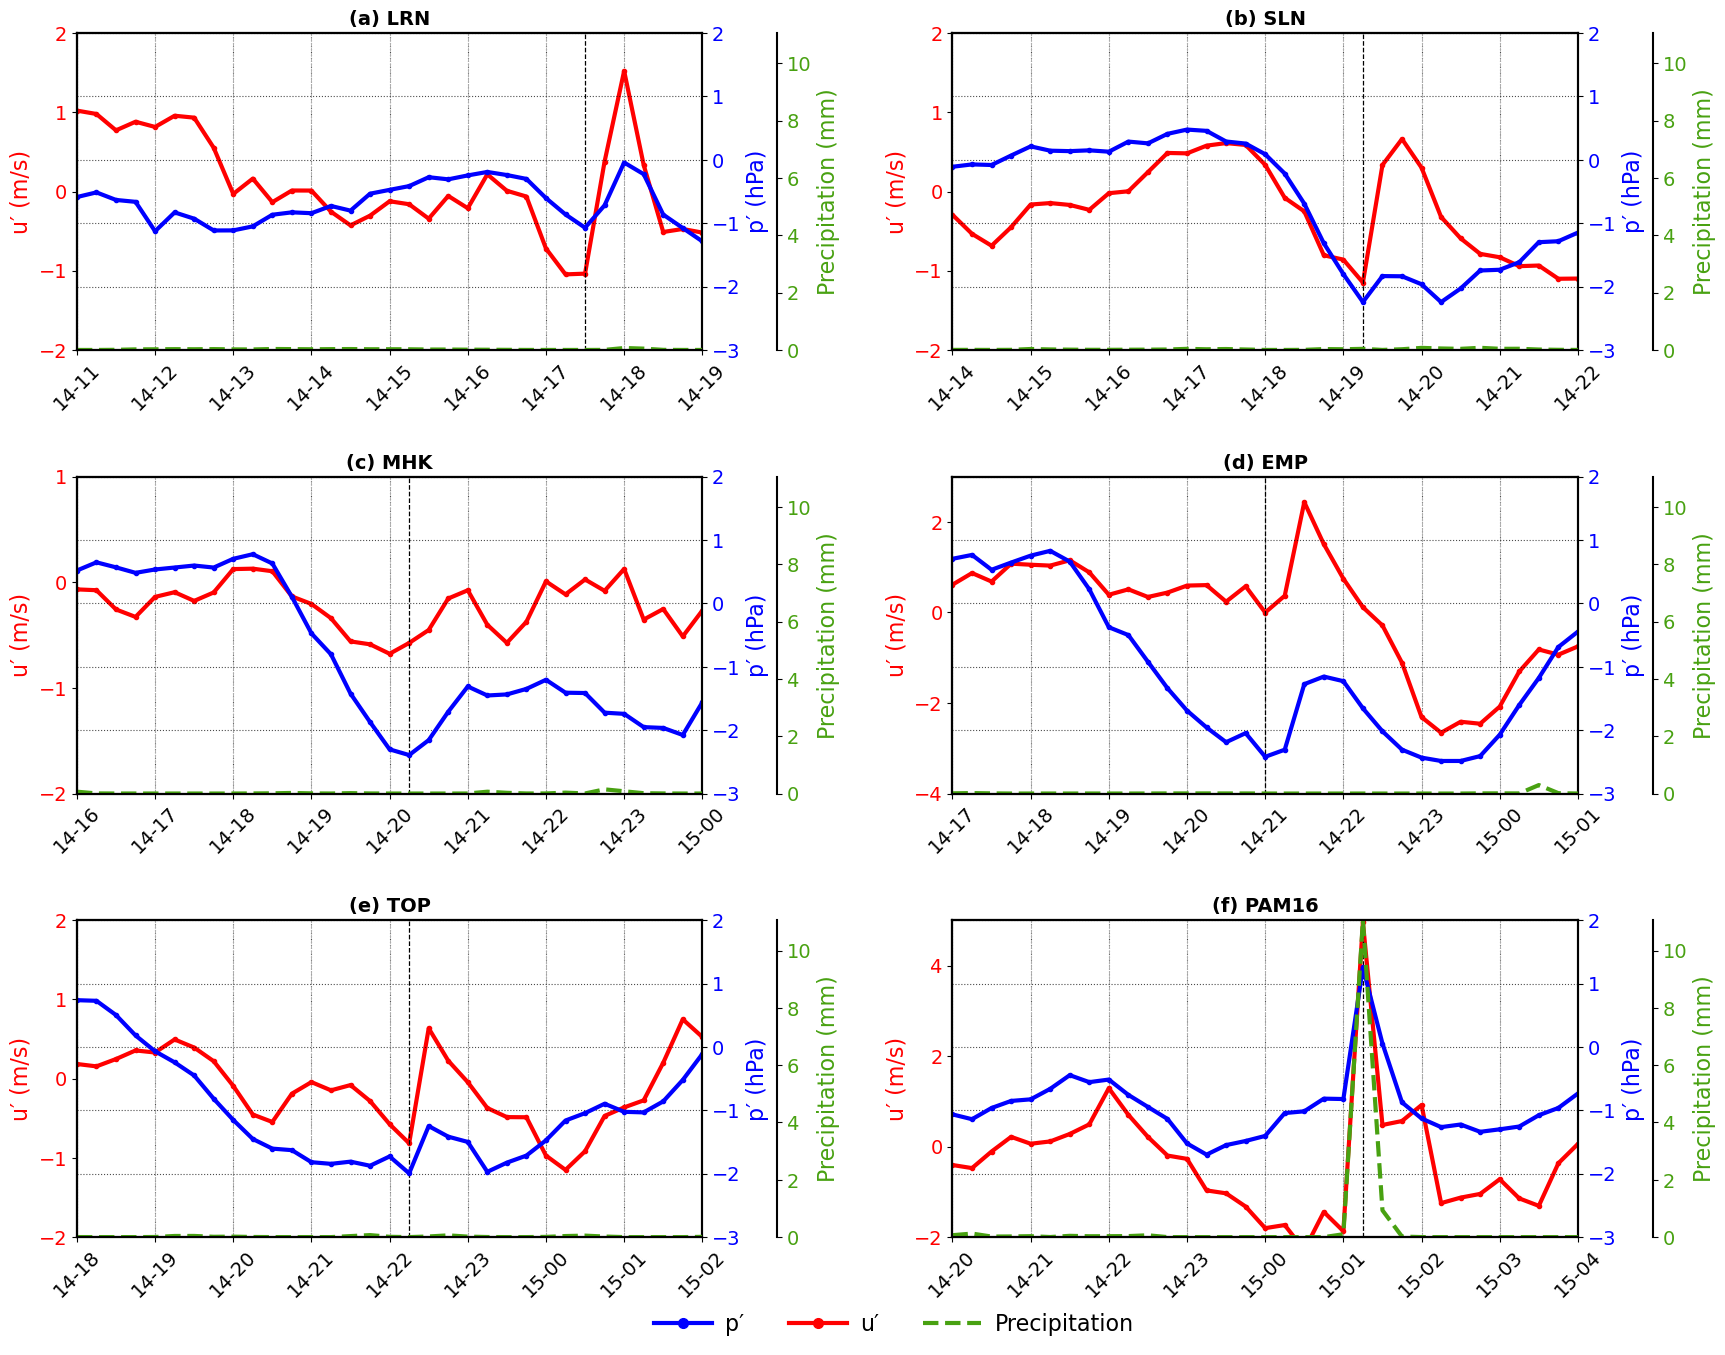

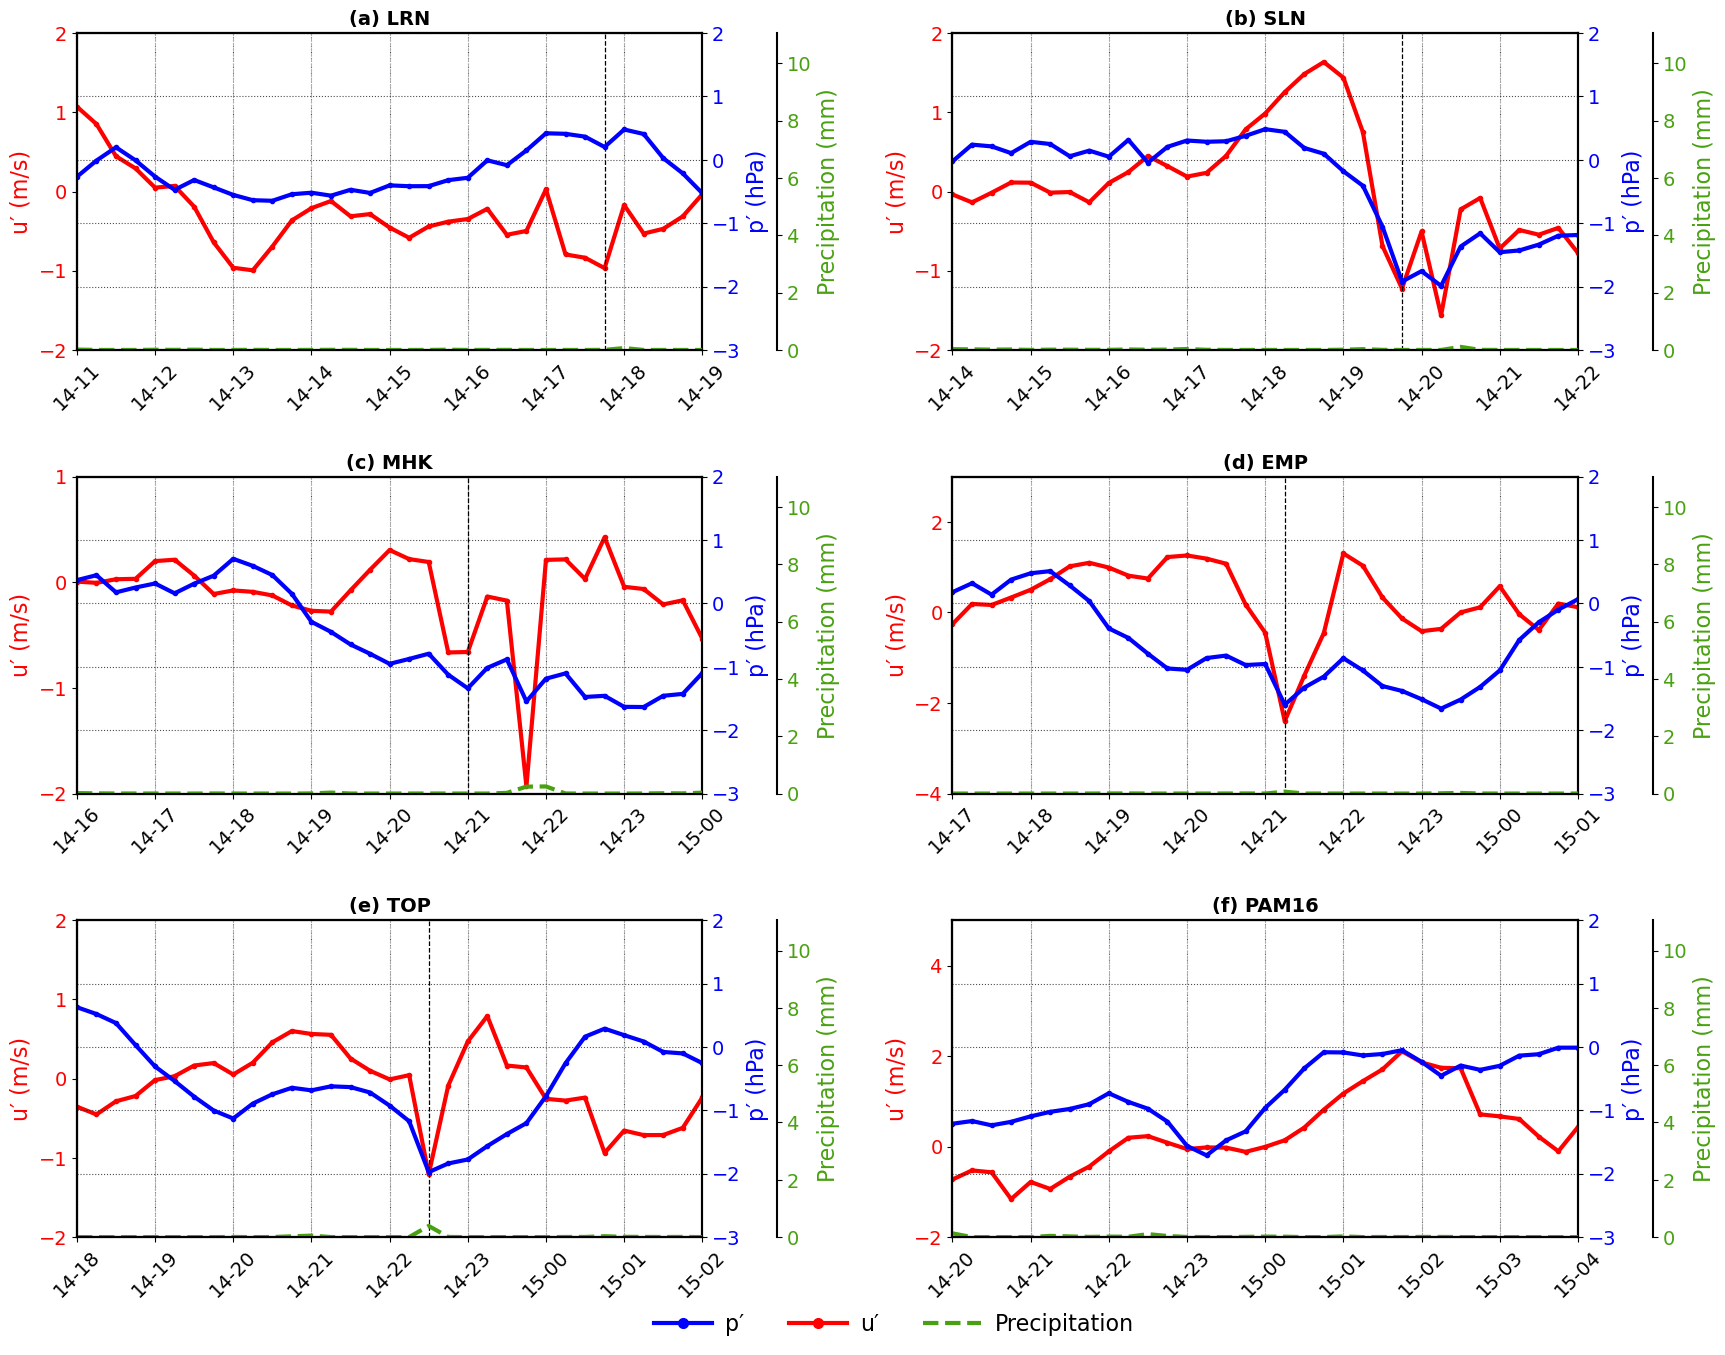

In [3]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from datetime import datetime
import pandas as pd

plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

AXIS_LABEL_FONTSIZE = 16
AXIS_TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 16
LEGEND_LINEWIDTH = 3
LEGEND_MARKERSIZE = 7

u_color = "#FF0000"
p_color = "#0000FF"
rain_color = "#48A111"

U_LABEL = "u′ (m/s)"
P_LABEL = "p′ (hPa)"
RAIN_LABEL = "Precipitation (mm)"

U_TICK_INTERVAL = {
    "(d) EMP": 2,
    "(f) PAM16": 2
}

runs = {
    "CNTRL": {
        "dataDir": "/glade/work/rbhandari/data/SIM_Feb14_MP2",
        "outfile": "CNTRL-QJRMS-SC.png",
        "theta_deg": {
            "(a) LRN": 192,
            "(b) SLN": 212,
            "(c) MHK": 211,
            "(d) EMP": 207,
            "(e) TOP": 203,
            "(f) PAM16": 250
        },
        "event_time": {
            "(a) LRN": datetime(1992, 2, 14, 17, 30),
            "(b) SLN": datetime(1992, 2, 14, 19, 15),
            "(c) MHK": datetime(1992, 2, 14, 20, 15),
            "(d) EMP": datetime(1992, 2, 14, 21, 0),
            "(e) TOP": datetime(1992, 2, 14, 22, 15),
            "(f) PAM16": datetime(1992, 2, 15, 1, 15)
        }
    },
    "SMT": {
        "dataDir": "/glade/derecho/scratch/rbhandari/SMOOTH-Terrain1/wrfv4.6.1/test/em_real",
        "outfile": "SMT-QJRMS-SC.png",
        "theta_deg": {
            "(a) LRN": 221,
            "(b) SLN": 219,
            "(c) MHK": 225,
            "(d) EMP": 230,
            "(e) TOP": 225,
            "(f) PAM16": 235
        },
        "event_time": {
            "(a) LRN": datetime(1992, 2, 14, 17, 45),
            "(b) SLN": datetime(1992, 2, 14, 19, 45),
            "(c) MHK": datetime(1992, 2, 14, 21, 0),
            "(d) EMP": datetime(1992, 2, 14, 21, 15),
            "(e) TOP": datetime(1992, 2, 14, 22, 30),
            "(f) PAM16": datetime(1992, 2, 15, 1, 45)
        }
    }
}

stations = {
    "(a) LRN": {
        "lat": 38.18, "lon": -99.10,
        "u_min": -2, "u_max": 2,
        "start": datetime(1992, 2, 14, 11),
        "end": datetime(1992, 2, 14, 19)
    },
    "(b) SLN": {
        "lat": 38.84, "lon": -97.61,
        "u_min": -2, "u_max": 2,
        "start": datetime(1992, 2, 14, 14),
        "end": datetime(1992, 2, 14, 22)
    },
    "(c) MHK": {
        "lat": 39.20, "lon": -96.60,
        "u_min": -2, "u_max": 1,
        "start": datetime(1992, 2, 14, 16),
        "end": datetime(1992, 2, 15, 0)
    },
    "(d) EMP": {
        "lat": 38.33, "lon": -96.19,
        "u_min": -4, "u_max": 3,
        "start": datetime(1992, 2, 14, 17),
        "end": datetime(1992, 2, 15, 1)
    },
    "(e) TOP": {
        "lat": 39.05, "lon": -95.69,
        "u_min": -2, "u_max": 2,
        "start": datetime(1992, 2, 14, 18),
        "end": datetime(1992, 2, 15, 2)
    },
    "(f) PAM16": {
        "lat": 38.37, "lon": -93.68,
        "u_min": -2, "u_max": 5,
        "start": datetime(1992, 2, 14, 20),
        "end": datetime(1992, 2, 15, 4)
    }
}

def read_wrf_time_from_file(fp):
    with nc.Dataset(fp, 'r') as f:
        if "Times" not in f.variables:
            raise KeyError("Times variable not found in file.")
        T = f.variables["Times"][:]
        row = T[0]
        if hasattr(row, "tobytes"):
            timestr = row.tobytes().decode("utf-8").strip()
        else:
            timestr = b"".join(row).decode("utf-8").strip()
        return datetime.strptime(timestr, "%Y-%m-%d_%H:%M:%S")

def apply_rolling_mean_mimic_matlab(data, window_size):
    reshaped = data.reshape(-1, data.shape[-1])
    smoothed = np.empty_like(reshaped, dtype=float)
    smoothed[:] = np.nan
    nt_local = reshaped.shape[1]
    half = window_size // 2

    for i in range(nt_local):
        start = max(0, i - half)
        end = min(nt_local, i + half + 1)
        smoothed[:, i] = np.nanmean(reshaped[:, start:end], axis=1)

    return smoothed.reshape(data.shape)

def nearest4_flat_indices(lat2d, lon2d, lat0, lon0):
    latr = np.radians(lat2d)
    lonr = np.radians(lon2d)
    lat0r = np.radians(lat0)
    lon0r = np.radians(lon0)

    dlat = latr - lat0r
    dlon = lonr - lon0r

    a = (
        np.sin(dlat / 2)**2
        + np.cos(latr) * np.cos(lat0r) * np.sin(dlon / 2)**2
    )

    a_flat = a.ravel()
    ok = np.isfinite(a_flat)

    if ok.sum() < 4:
        raise ValueError("Not enough finite grid points to select 4 nearest.")

    ok_idx = np.where(ok)[0]
    sub = a_flat[ok_idx]

    k = 4
    part = np.argpartition(sub, k - 1)[:k]
    best = ok_idx[part]
    best = best[np.argsort(a_flat[best])]

    return best

def mean_of_4(series2d, idx4):
    return np.nanmean(series2d[idx4, :], axis=0)

def load_run(dataDir):
    raw_files = sorted([
        os.path.join(dataDir, f) for f in os.listdir(dataDir)
        if f.startswith('wrfout_d03_')
    ])

    if not raw_files:
        raise FileNotFoundError(f"No wrfout_d03_ files found in {dataDir}")

    file_time_pairs = []
    skipped = 0

    for fp in raw_files:
        try:
            tt = read_wrf_time_from_file(fp)
            file_time_pairs.append((fp, tt))
        except Exception as e:
            skipped += 1
            print(f"Skipping file: {fp}")
            print(f"Reason: {e}")

    if not file_time_pairs:
        raise RuntimeError(f"No readable wrfout files with valid Times were found in {dataDir}")

    file_time_pairs.sort(key=lambda x: x[1])
    fileList = [p for p, _ in file_time_pairs]
    t = pd.to_datetime([tt for _, tt in file_time_pairs])

    print("")
    print(f"Data directory: {dataDir}")
    print(f"Readable files used: {len(fileList)}")
    print(f"Skipped files: {skipped}")
    print(f"Time start: {t[0]}")
    print(f"Time end:   {t[-1]}")

    if len(t) >= 2:
        dts = np.unique(np.diff(t.values).astype("timedelta64[s]").astype(int))
        print(f"Unique dt seconds: {dts}")

    with nc.Dataset(fileList[0], 'r') as f:
        lon = np.squeeze(f.variables['XLONG'][:])
        lat = np.squeeze(f.variables['XLAT'][:])

    all_u10, all_v10, all_sfc = [], [], []
    all_rainc, all_rainnc, all_rainsh = [], [], []

    for fp in fileList:
        with nc.Dataset(fp, 'r') as f:
            all_u10.append(np.squeeze(f.variables['U10'][:]))
            all_v10.append(np.squeeze(f.variables['V10'][:]))
            all_sfc.append(np.squeeze(f.variables['PSFC'][:]))
            all_rainc.append(np.squeeze(f.variables['RAINC'][:]))
            all_rainnc.append(np.squeeze(f.variables['RAINNC'][:]))
            all_rainsh.append(np.squeeze(f.variables['RAINSH'][:]))

    all_u10 = np.stack(all_u10, axis=-1)
    all_v10 = np.stack(all_v10, axis=-1)
    all_sfc = np.stack(all_sfc, axis=-1)
    all_rainc = np.stack(all_rainc, axis=-1)
    all_rainnc = np.stack(all_rainnc, axis=-1)
    all_rainsh = np.stack(all_rainsh, axis=-1)

    nt = all_u10.shape[-1]

    u10_r = all_u10.reshape(-1, nt)
    v10_r = all_v10.reshape(-1, nt)
    psfc_r = all_sfc.reshape(-1, nt)

    rain_total = all_rainc + all_rainnc + all_rainsh
    rain_diff = np.diff(rain_total, axis=-1)
    rain_diff = np.concatenate([np.zeros_like(rain_total[..., [0]]), rain_diff], axis=-1)
    rain_r = rain_diff.reshape(-1, nt)

    return {
        "t": t,
        "lat": lat,
        "lon": lon,
        "u10_r": u10_r,
        "v10_r": v10_r,
        "psfc_r": psfc_r,
        "rain_r": rain_r
    }

def get_station_series(run_data, station_name, theta_deg):
    info = stations[station_name]

    t = run_data["t"]
    lat = run_data["lat"]
    lon = run_data["lon"]

    idx4 = nearest4_flat_indices(lat, lon, info["lat"], info["lon"])
    mask_plot = (t >= info["start"]) & (t <= info["end"])

    u10_4 = mean_of_4(run_data["u10_r"], idx4)
    v10_4 = mean_of_4(run_data["v10_r"], idx4)
    psfc_4 = mean_of_4(run_data["psfc_r"], idx4)
    rain_4 = mean_of_4(run_data["rain_r"], idx4)

    theta = np.radians(theta_deg)

    wind = -u10_4 * np.sin(theta) - v10_4 * np.cos(theta)
    w_smooth = apply_rolling_mean_mimic_matlab(wind[None, :], 48).squeeze(0)
    u_prime = wind - w_smooth

    psfc_s = apply_rolling_mean_mimic_matlab(psfc_4[None, :], 48).squeeze(0)
    p_prime = (psfc_4 - psfc_s) / 100.0

    return {
        "mask_plot": mask_plot,
        "u_prime": u_prime,
        "p_prime": p_prime,
        "rain": rain_4
    }

def build_all_series(all_data):
    all_series = {}

    for run_name, run_info in runs.items():
        all_series[run_name] = {}

        for station_name in stations:
            theta_deg = run_info["theta_deg"][station_name]
            all_series[run_name][station_name] = get_station_series(
                all_data[run_name],
                station_name,
                theta_deg
            )

    return all_series

def get_global_limits(all_series):
    p_min = np.inf
    p_max = -np.inf
    rain_min = np.inf
    rain_max = -np.inf

    for run_name in runs:
        for station_name in stations:
            series = all_series[run_name][station_name]
            mask = series["mask_plot"]

            pwin = series["p_prime"][mask]
            rwin = series["rain"][mask]

            if pwin.size > 0 and np.isfinite(pwin).any():
                p_min = min(p_min, np.nanmin(pwin))
                p_max = max(p_max, np.nanmax(pwin))

            if rwin.size > 0 and np.isfinite(rwin).any():
                rain_min = min(rain_min, np.nanmin(rwin))
                rain_max = max(rain_max, np.nanmax(rwin))

    if not np.isfinite(p_min):
        p_min, p_max = -1, 1

    if not np.isfinite(rain_min):
        rain_min, rain_max = 0, 1

    p_axis_min = np.floor(p_min)
    p_axis_max = np.ceil(p_max)

    if p_axis_min == p_axis_max:
        p_axis_min -= 1
        p_axis_max += 1

    if rain_min == rain_max:
        rain_min = 0
        rain_max += 1

    return p_axis_min, p_axis_max, rain_min, rain_max

def plot_run(run_name, all_data, all_series, p_axis_min, p_axis_max, rain_axis_min, rain_axis_max):
    run_info = runs[run_name]
    t = all_data[run_name]["t"]

    fig, axes = plt.subplots(3, 2, figsize=(19, 14), sharex=False)
    axes = np.atleast_2d(axes)

    for ax1, station_name in zip(axes.ravel(), stations.keys()):
        info = stations[station_name]
        series = all_series[run_name][station_name]

        mask_plot = series["mask_plot"]
        u_prime = series["u_prime"]
        p_prime = series["p_prime"]
        rain_series = series["rain"]

        ax1.plot(
            t[mask_plot], u_prime[mask_plot],
            color=u_color, lw=3,
            marker='o', markersize=3,
            markerfacecolor=u_color, markeredgecolor=u_color,
            markevery=1
        )

        ax1.set_ylabel(U_LABEL, color=u_color, fontsize=AXIS_LABEL_FONTSIZE)
        ax1.tick_params(axis='y', labelcolor=u_color, labelsize=AXIS_TICK_FONTSIZE)
        ax1.tick_params(axis='x', labelsize=AXIS_TICK_FONTSIZE)
        ax1.set_ylim(info["u_min"], info["u_max"])

        u_tick = U_TICK_INTERVAL.get(station_name, 1)
        ax1.yaxis.set_major_locator(MultipleLocator(u_tick))

        if mask_plot.any():
            ax1.set_xlim(t[mask_plot][0], t[mask_plot][-1])

            for tick in pd.date_range(t[mask_plot][0], t[mask_plot][-1], freq='1h'):
                ax1.axvline(
                    tick,
                    color='black',
                    ls=':',
                    lw=0.8,
                    zorder=0,
                    alpha=0.7
                )

        ax1.grid(True, axis='x', ls='--', lw=0.7)
        ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%H'))
        ax1.tick_params(axis='x', rotation=45, labelsize=AXIS_TICK_FONTSIZE)

        ax2 = ax1.twinx()

        ax2.plot(
            t[mask_plot], p_prime[mask_plot],
            color=p_color, lw=3,
            marker='o', markersize=3,
            markerfacecolor=p_color, markeredgecolor=p_color,
            markevery=1
        )

        ax2.set_ylabel(P_LABEL, color=p_color, fontsize=AXIS_LABEL_FONTSIZE)
        ax2.tick_params(axis='y', labelcolor=p_color, labelsize=AXIS_TICK_FONTSIZE)
        ax2.set_ylim(p_axis_min, p_axis_max)
        ax2.yaxis.set_major_locator(MultipleLocator(1))

        ax2.yaxis.grid(
            True,
            which='major',
            linestyle=':',
            linewidth=0.8,
            color='black',
            alpha=0.7
        )

        ax3 = ax1.twinx()
        ax3.spines['right'].set_position(('axes', 1.12))

        ax3.plot(
            t[mask_plot], rain_series[mask_plot],
            color=rain_color,
            lw=3,
            ls='--'
        )

        ax3.set_ylabel(RAIN_LABEL, color=rain_color, fontsize=AXIS_LABEL_FONTSIZE)
        ax3.tick_params(axis='y', labelcolor=rain_color, labelsize=AXIS_TICK_FONTSIZE)
        ax3.set_ylim(rain_axis_min, rain_axis_max)

        if not (run_name == "SMT" and station_name == "(f) PAM16"):
            ax1.axvline(
                run_info["event_time"][station_name],
                color='black',
                ls='--',
                lw=0.9,
                zorder=5
            )

        ax1.set_title(f"{station_name}", fontsize=14, fontweight='bold')

    legend_handles = [
        Line2D(
            [0], [0],
            color=p_color,
            lw=LEGEND_LINEWIDTH,
            marker='o',
            markersize=LEGEND_MARKERSIZE,
            markerfacecolor=p_color,
            markeredgecolor=p_color,
            label="p′"
        ),
        Line2D(
            [0], [0],
            color=u_color,
            lw=LEGEND_LINEWIDTH,
            marker='o',
            markersize=LEGEND_MARKERSIZE,
            markerfacecolor=u_color,
            markeredgecolor=u_color,
            label="u′"
        ),
        Line2D(
            [0], [0],
            color=rain_color,
            lw=LEGEND_LINEWIDTH,
            ls='--',
            label="Precipitation"
        )
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        fontsize=LEGEND_FONTSIZE,
        bbox_to_anchor=(0.5, 0.015),
        handlelength=2.6,
        columnspacing=2.0,
        handletextpad=0.6
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.86,
        bottom=0.10,
        top=0.96,
        wspace=0.40,
        hspace=0.40
    )

    plt.savefig(run_info["outfile"], dpi=600, bbox_inches="tight")
    plt.show()

all_data = {}

for run_name in runs:
    all_data[run_name] = load_run(runs[run_name]["dataDir"])

all_series = build_all_series(all_data)

p_axis_min, p_axis_max, rain_axis_min, rain_axis_max = get_global_limits(all_series)

print("")
print("Shared axis limits used for both CNTRL and SMT:")
print(f"p′ axis: {p_axis_min} to {p_axis_max} hPa")
print(f"Precipitation axis: {rain_axis_min} to {rain_axis_max} mm")

plot_run(
    "CNTRL",
    all_data,
    all_series,
    p_axis_min,
    p_axis_max,
    rain_axis_min,
    rain_axis_max
)

plot_run(
    "SMT",
    all_data,
    all_series,
    p_axis_min,
    p_axis_max,
    rain_axis_min,
    rain_axis_max
)